In [ ]:
%%capture
!apt install python3-dev graphviz libgraphviz-dev pkg-config
!pip install pywhy-graphs
!pip install networkx pygraphviz matplotlib

In [ ]:
import warnings
import random
from itertools import combinations
from typing import List, Set, Tuple, Optional
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx
from networkx import Graph, DiGraph
from networkx.drawing.nx_agraph import graphviz_layout
import pywhy_graphs as pg
import pywhy_graphs.viz as viz

warnings.filterwarnings("ignore")

**CAUSAL NETWORK PROJECT**

Author:
* Anna Marika Biasco

# Introduction

This notebook aims to facilitate the understanding of the referenced paper and demonstrate an implementation along with examples of the algorithms presented in the study.  

**Citation:**  
Van der Zander, B., & Liśkiewicz, M. (2020). *Finding Minimal d-Separators in Linear Time and Applications*. *Proceedings of The 35th Uncertainty in Artificial Intelligence Conference*, in *Proceedings of Machine Learning Research*, 115:637-647. Available at: [https://proceedings.mlr.press/v115/van-der-zander20a.html](https://proceedings.mlr.press/v115/van-der-zander20a.html).

D-separation is a fundamental concept in causal inference, used to verify conditional independence between variables in a **Directed Acyclic Graph (DAG)**. It ensures that a given causal model is consistent with the observed probability distribution. A key application is the identification of causal effects from observational data through **adjustment sets**, as recent studies have shown that their determination can be reduced to d-separation, improving computational efficiency. Additionally, d-separation plays a crucial role in identifying **conditional instrumental variables** and **generalized instrumental sets**, which are essential for parameter estimation in linear models.

The paper introduces an efficient algorithm for computing a **minimal** d-separator in linear time, specifically in $O(n + m)$, where $n$ denotes the number of nodes and $m$ the number of edges in the graph. Unlike previous approaches, this method identifies a separation set while ensuring minimality—a property that significantly increases the computational complexity of the problem.

Moreover, the proposed algorithms extend beyond DAGs and are applicable to more general causal structures, including **Ancestral Graphs (AGs)**, **Maximal Ancestral Graphs (MAGs)**, **Completed Partially Directed Acyclic Graphs (CPDAGs)**, and **Restricted Chain Graphs (RCGs)**.

A key contribution of this study is the development of a method for finding a minimal d-separator without computing the **moral graph**, which is a significant improvement over previous approaches. The first non-trivial algorithms for identifying minimal d-separators in DAGs were introduced by Tian, Paz, and Pearl over two decades ago (Tian, J., Paz, A., & Pearl, J. (1998). Finding minimal d-separators. Tech. Rep. R-254, University of California, Los Angeles). While their algorithms have remained the most efficient to date, they require constructing the moral graph, which, for certain DAGs with $n$ nodes and $m$ edges, can contain up to $O(m^2)$ edges. The method proposed by Van der Zander and Liśkiewicz overcomes this limitation by achieving linear time complexity without relying on moralization.

This notebook provides an in-depth exploration of these algorithms, demonstrating their implementation and application.

 We will address general variants of problems, where:  

- $X$ and $Y$ are disjoint and non-empty subsets of nodes in $V$.  
- $Z$ is a minimal d-separator, meaning that no proper subset of $Z$ is still a d-separator between $X$  and $Y$ in the graph $G$.  
- Additionally, we impose the constraint $ I \subseteq Z \subseteq R $ for given subsets $I, R $ of $V$, with $ I \subseteq R $. This means that the nodes in $I$ (even if empty) must always be included in the d-separator, even if the set would remain a separator without them.  
- The set $ V \setminus R $ corresponds to the unobserved nodes.


To provide a clear and comprehensive explanation of the algorithmic implementation, each step will be examined in detail alongside its corresponding code. This structured approach ensures transparency, enhances understanding, and eliminates potential ambiguities.

# Implementation

## Minimal d-Separators in DAGs


In this section, we demonstrate how to test and find minimal d-separators in DAGs directly, without computing the moral graph.

The underlying idea is to select a minimal separator set $Z$ as follows:  

$$
Z = (A \cap R \cap X^\star \cap Y^\star) \cup I
$$

which automatically satisfies the minimality criterion.  

Where:  
- Let $A$ be the set of ancestors of $X \cup Y \cup I$, i.e., $A = An(X \cup Y \cup I)$.  
- Let $X^\star$ (respectively $Y^\star$) be the closure of $X$ (respectively $Y$), meaning the set of all nodes $V$ for which there exists a path from $X$ (or $Y$) to $V$ that contains only nodes in $A$ and no non-collider in $Z$.  

However, this expression cannot be used directly, as $X^\star$ and $Y^\star$ cannot be computed without knowing $Z$.  

**Solution:**  
- Perform the intersections sequentially.  
- Compute $X^\star$ using an initial separator $Z_0$.  
- From this, obtain a new separator, which can then be used to compute $Y^\star$.

### Identification of Ancestors

So, as a first step, we implement a support function that allows us to compute the ancestors of a given set of nodes.

In [ ]:
def an(G: DiGraph, V: Set[str]) -> Set[str]:
  """
  Computes the set of ancestors for a given set of nodes in a Directed Acyclic Graph (DAG).
  Parameters:
      G (DiGraph): A directed acyclic graph (DAG).
      V (Set[str]): A set of nodes for which ancestors need to be determined.

  Returns:
      Set[str]: The set of all ancestor nodes of V in G.

  """
  # Compute ancestors for each node in V and merge into a single set
  An_V = {an_v for v in V for an_v in nx.ancestors(G, v)}
  return An_V

### Closure

The sets $X^\star$ and $Y^\star$ can be efficiently computed in $O(n + m)$ time using an algorithm similar to the Bayes-Ball algorithm, with two key differences:  
- When starting from the initial nodes $X$ (or $Y$), the traversal is restricted to nodes within a given set $A$.  
- The rules for individual traversal steps are modified.  

The new traversal rules in the algorithm are as follows:  
- Assume $V \in A$.  
- A combination (edge type $e$, node $V$, edge type $f$, neighboring node $N$) is "traversable" if and only if $N \in A$ and, if $V \in Z$, then $V$ is a collider in the path $(e, V, f)$.

Let's implement a function that allows us to compute the closure of a set of nodes.

In [ ]:
def pass_bayes_ball_DAG(e, V, f, N, A, Z) -> bool:
  """
  Determines whether the Bayes Ball can pass through a given node in a Directed Acyclic Graph (DAG)
  Parameters:
      e (str): The direction of the edge entering V:
            - "in"  (traversing into V from a parent, i.e., U → V)
            - "out" (traversing into V from a child, i.e., U ← V)
      V (str): The current node being evaluated.
      f (str): The direction of the edge exiting V towards N:
            - "in"  (V → N, i.e., moving from parent to child)
            - "out" (V ← N, i.e., moving from child to parent)
      N (str): The neighbor node of V, which is being checked for traversal.
      A (Set[str]): The set of nodes that restrict movement; the ball cannot pass to nodes
                      outside this set.
      Z (Set[str]): The separator set, which blocks traversal if V is in Z (unless it's a collider).

  Returns:
      bool: True if the Bayes Ball can pass from V to N, False otherwise.

  """
  is_collider = (e == "in" and f == "out")
  return (N in A) and (V not in Z or is_collider)

Once the method for checking the traversal rules is constructed, we need to build the method for computing the closure.  
We can consider it a version specifically for DAGs, compared to the other reachable function implemented in the "General Algorithms" section.

To compute the closure of a given set $X$, i.e., the set of reachable nodes in a DAG starting from the initial set of nodes $X$:

1. **Initialize an empty queue (`Q`)** to manage the nodes to explore.  
2. **Add the initial nodes (`X`) to the queue**, and create a copy of $Q$ (`P`), with the same nodes, to keep track of visited nodes and avoid revisiting them.  
3. **Start a loop until `Q` is empty**:  
   - **Extract a node (`V`) and edge type (`e`) from `Q`**.  
   - **Find all neighboring nodes of `V`** (predecessors and successors).  
   - **For each neighboring node (`N`) and edge type (`f`)**:  
     - If **it has not been visited already** and **can be traversed** (according to the `pass_DAG` function), add it to both `Q` and `P`.  
4. **When the queue `Q` is empty, the algorithm terminates**.  
5. **Return the set of reachable nodes**.

In [ ]:
def reachableDAG(G: nx.DiGraph, X: Set[str] = set(),
                 A: Set[str] = set(), Z: Set[str] = set()) -> Set[str]:
    """
    Computes the reachability closure of the given set X in a Directed Acyclic Graph (DAG).

    This function finds all nodes that can be reached from X by considering both predecessors
    (incoming edges) and successors (outgoing edges), while applying constraints based on:
    - A: Allowed ancestor nodes for traversal.
    - Z: Blocked nodes that restrict traversal.

    Parameters:
        G (nx.DiGraph): A directed acyclic graph.
        X (Set[str]): The initial set of nodes from which reachability is computed.
        A (Set[str], optional): Nodes that define the allowed traversal region.
        Z (Set[str], optional): Nodes that block traversal.

    Returns:
        Set[str]: The set of all reachable nodes from X under the given constraints.
    """

    queue = deque([("out", node) for node in X])
    visited = set(queue)  # Track visited nodes to avoid redundant processing

    while queue:
        e, V = queue.popleft()

        # Get predecessors (incoming edges) and successors (outgoing edges)
        neighbors = [("out", N) for N in G.pred[V]] + [("in", N) for N in G.succ[V]]

        for f, N in neighbors:
            # Check Bayes Ball conditions before traversing
            if (f, N) not in visited and pass_bayes_ball_DAG(e=e, V=V, f=f, N=N, A=A, Z=Z):
                queue.append((f, N))
                visited.add((f, N))

    return {node for _, node in visited}

### Finding Minimal Separator in a DAGs

In [ ]:

def findMinSepInDAG(G: DiGraph, X: Set[str] = set(), Y: Set[str] = set(),
                    I: Set[str] = set(), notR: Set[str] = set()):
  """
  Finds a minimal separating set (Z) in a Directed Acyclic Graph (DAG) that blocks
  all paths between X and Y while respecting an allowed set of nodes.
  Parameters:
        G (DiGraph): A directed acyclic graph (DAG).
        X (Set[str]): The first set of nodes to be separated.
        Y (Set[str]): The second set of nodes to be separated from X.
        I (Set[str]): A set of required nodes that must be included in Z.
        notR (Set[str]): A set of nodes that should be excluded from the separation process, nunobserved nodes.

  Returns:
        Set[str] or None:
          - The minimal separating set Z such that X and Y are d-separated.
          - Returns None if no valid separation exists.

  """
  R = set(G.nodes) - notR
  XYI = X | Y | I
  A = an(G, XYI) | XYI
  # Initialize Z as nodes in R that are ancestors but not in X or Y
  Z_init = R & (A - (X | Y))
  # Compute the closure of X under the given ancestor set and initial separator Z
  X_closure = reachableDAG(G, X, A, Z_init)
  # If X's closure reaches Y, separation is impossible
  if X_closure & Y:
    return None

  # Refine Z by keeping only nodes in the closure of X or required set I
  Z_updated = Z_init & (X_closure | I)

  Y_closure = reachableDAG(G, Y, A, Z_updated)

  return Z_updated & (Y_closure | I)

## General Algorithms

Since a DAG is also an AG and an RCG, and the algorithms for DAGs described are a special case of the algorithms presented here, it follows that the correctness of the algorithms for DAGs is also demonstrated. Furthermore, given the relationship $MAG \subseteq AG$ and $CPDAG \subseteq RCG$, our algorithms are valid for both MAGs and CPDAGs as well.

We need to follow the same steps used for DAGs, but within the context of AGs and RCGs. These steps are adapted with some modifications to properly handle bidirectional, undirected edges, and separation constraints.

### Possible Ancestors

In [ ]:
def possible_an(G: pg.networkx.MixedEdgeGraph, S: Set[str]) -> Set[str]:
    """
    Computes the set of possible ancestors (pAn) for a given set of nodes S in a mixed-edge graph.

    In a MixedEdgeGraph (such as an Ancestral Graph or a Maximal Ancestral Graph), a node A is considered
    a possible ancestor of node B if there exists a directed path from A to B without passing through
    a bidirected edge (↔). This function explores the directed edges to determine the possible ancestors.

    Parameters:
        G (MixedEdgeGraph): A pywhy MixedEdgeGraph containing directed and possibly bidirected edges.
        S (Set[str]): A set of nodes for which possible ancestors need to be determined.

    Returns:
        Set[str]: The set of possible ancestors (pAn) of the nodes in S.
    """

    pAn = set()
    queue = deque(S)  # Use deque for efficient popping from the front

    # Process nodes in BFS order
    while queue:
        current_node = queue.popleft()
        for neighbor in G.neighbors(current_node):
            for edge_type in G.edge_types:
                # A node is a possible ancestor if there is a directed edge neighbor → current_node
                if (
                    G.has_edge(neighbor, current_node, edge_type=edge_type) and
                    neighbor not in pAn and
                    edge_type != 'bidirected'  # Ignore bidirected edges
                ):
                    pAn.add(neighbor)
                    queue.append(neighbor)

    return pAn

### New Bayes-Ball Algorithm for AGs and RCGs

Expanded rules for Bayes-Ball in AGs and RCGs:

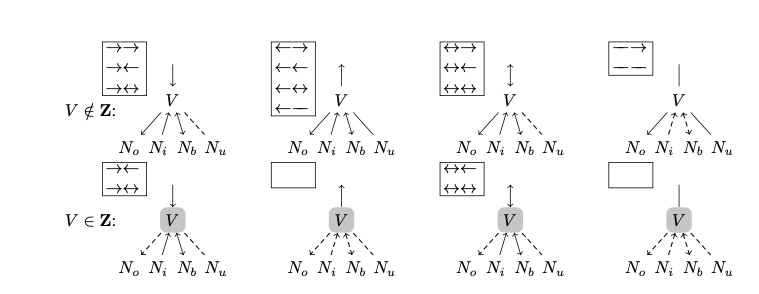

1. **Entry into a Node**: The ball enters a node through a **parent edge** and must decide how to propagate to the available exits.

2. **Types of Edges**: Four possible types of edges for entry and exit are considered:  
  - $V \rightarrow N_o$ (out-node)  
  - $V \leftrightarrow N_b$ (bidirectional edge)  
  - $V \leftarrow N_i$ (in-node)  
  - $V - N_u$ (undirected edge).

3. **Bouncing Ball**:  
   - If the ball enters a node **V** and follows a path that immediately returns to the same entry edge, it is said that the ball "bounces." This can occur when a constraint prevents further propagation.

4. **Separation Condition**:  
   - If a node **V** (shown in gray) is in the conditioning set **Z**, the valid combinations are listed in the boxes below.  
   - If a node **V** is not in the conditioning set **Z**, the combinations of edge pairs through which the ball can pass are listed in the boxes (top frames).




The modifications compared to the classical version of the Bayes-Ball algorithm are aimed at handling the new types of edges and constraints present in **AGs and RCGs**, ensuring that the algorithm can be used to correctly determine **conditional separations** in these more general graphs.


In [ ]:
def pass_bayes_ball(e: str, V: str, f: str, N: str, A: Set[str], Z: Set[str]) -> bool:
    """
    Determines whether the Bayes Ball can pass through a given node in a mixed graph.

    The function evaluates if the Bayes Ball traversal is allowed based on the
    type of edge, the presence of the node in a restricted set (A), and whether
    the node is in the separator set (Z). The traversal rules are derived from
    conditional independence properties in graphical models.

    Parameters:
        e (str): The direction of the entering edge ("in", "out", "bi", "un").
        V (str): The current node being evaluated.
        f (str): The direction of the exiting edge relative to the neighbor ("in", "out", "bi", "un").
        N (str): The neighbor node of V.
        A (Set[str]): The set of nodes that restrict Bayes Ball movement;
                      the ball cannot pass to nodes outside this set.
        Z (Set[str]): The separator set that blocks certain paths.

    Returns:
        bool: True if the Bayes Ball can pass through the node, False otherwise.
    """

    if N not in A:
        return False  # Ball can only pass to nodes in A

    # Define valid edge transitions
    if V not in Z:
        pass_combinations = {
            ("in", "in"), ("in", "out"), ("in", "bi"),
            ("out", "in"), ("out", "out"), ("out", "bi"), ("out", "un"),
            ("bi", "in"), ("bi", "out"), ("bi", "bi"),
            ("un", "in"), ("un", "un")
        }
    else:
        pass_combinations = {
            ("in", "out"), ("in", "bi"),
            ("bi", "out"), ("bi", "bi")
        }

    return (e, f) in pass_combinations

We utilize the previously implemented function to construct the **REACHABLE** algorithm described in the paper. This algorithm identifies all nodes $ W \in \mathbf{V} $ that are reachable from a given node $ X \in \mathbf{X} $ via an *almost definite status walk*. In this context, the path must satisfy two conditions: (i) all non-colliders must not belong to $ \mathbf{Z} $, and (ii) traversal is restricted to nodes in $ \mathbf{A} $.

From the paper, we know that **Lemma 4.2** states: if a path $ \pi $ is an almost definite status walk connecting $ X $ and $ Y $ that remains active given $ Z $, then all nodes in $ \pi $ belong to the partial ancestral set $ pAn(X \cup Y \cup Z) $.  

A path $ \pi $ in a mixed graph $ G $ is considered **active** given a set $ Z $ if and only if (i) every non-collider along the path does not belong to $ Z $, and (ii) every collider lies within the $ An(Z) $.

In [ ]:
def reachable(G: pg.networkx.MixedEdgeGraph, X: Set[str], A: Set[str], Z: Set[str]) -> Set[str]:
    """
    Computes the closure of a node set X in a mixed-edge graph using an almost definite status walk.

    The closure consists of all nodes reachable from X, considering that:
    - All non-collider nodes must not be in the separator set Z.
    - The traversal is restricted to nodes in the allowed set A.
    - Different edge types (directed, bidirected, undirected) influence the traversal rules.

    Parameters:
        G (MixedEdgeGraph): A pywhy MixedEdgeGraph.
        X (Set[str]): The set of nodes whose closure is calculated.
        A (Set[str]): The set of allowed nodes; the closure cannot extend beyond this set.
        Z (Set[str]): The separator set that restricts traversal through non-collider nodes.

    Returns:
        Set[str]: The closure of X, representing all nodes reachable under the given constraints.
    """

    # Queue stores (edge type, node) pairs to explore
    queue = deque([("out", node) for node in X])
    visited = set(queue)  # Track visited (edge type, node) pairs

    while queue:
        e, V = queue.popleft()

        # Identify all neighbors and their edge types
        edge_node_pairs = [
            ("in", N) if G.has_edge(V, N, edge_type='directed') else
            ("out", N) if G.has_edge(N, V, edge_type='directed') else
            ("bi", N) if G.has_edge(V, N, edge_type='bidirected') else
            ("un", N) if G.has_edge(V, N, edge_type='undirected') else None
            for N in G.neighbors(V)
        ]

        # Filter out invalid edges (i.e., None values)
        edge_node_pairs = [(f, N) for f, N in edge_node_pairs if f]

        # Explore valid neighbors
        for f, N in edge_node_pairs:
            if (f, N) not in visited and pass_bayes_ball(e=e, V=V, f=f, N=N, A=A, Z=Z):
                queue.append((f, N))
                visited.add((f, N))

    # Extract unique nodes from visited pairs
    return {node for _, node in visited}

Each node is visited only once by each adjacent edge; therefore, the execution time is $O(n + m)$.

### Verification of the criterion of minimality

An algorithm that verifies the minimality criterion, i.e.,  
A set $ Z $ is a minimal d-separator under the constraint $ I \subseteq Z \subseteq R $ if and only if it satisfies the following minimality criterion:

1. $ \mathbf{X^\star \cap Y = \emptyset} $
2. $ \mathbf{I \subseteq Z \subseteq A \cap R} $
3. $ \mathbf{Z \setminus I} $ is a subset of $ \mathbf{ X^\star \cap Y^\star} $




- The **first condition** states that the set $ Z $ is indeed a separator, as it blocks all paths between $ X $ and $ Y $.  
- The **second condition** is a basic constraint.  
- The **third condition** checks that $ \mathbf{Z}$ is minimal: for every node $ Z \in \mathbf{Z \setminus I}$, there exist a path from $ \mathbf{X} $ to $ Z $ and a path from $ \mathbf{Y} $ to $ Z $.  
Thus, if $ Z $ were removed from $ \mathbf{Z} $, these paths would meet, and $ \mathbf{Z} $ would no longer be a separator.

In [ ]:
def test_min_sep(G: pg.networkx.MixedEdgeGraph, X: Set[str] = set(), Y: Set[str] = set(),
                    I: Set[str] = set(), notR: Set[str] = set(), Z: Set[str] = set()) -> bool:
    """
    Checks if a given set Z is a minimal separator for node sets X and Y in a mixed-edge graph G.

    A minimal separator satisfies the following conditions:
    1. It contains all required nodes in I.
    2. It does not contain any node from notR.
    3. It consists only of nodes from the ancestor set of X ∪ Y ∪ I.
    4. It separates X from Y.
    5. Every node in Z \ I is necessary for separation.

    Parameters:
        G (pg.networkx.MixedEdgeGraph): A pywhy MixedEdgeGraph.
        X (Set[str]): Set of nodes to be separated.
        Y (Set[str]): Set of nodes to be separated.
        I (Set[str]): Nodes that must be included in the separator.
        notR (Set[str]): Nodes that must not be included in the separator.
        Z (Set[str]): Candidate separator set.

    Returns:
        bool: True if Z is a minimal separator, False otherwise.
    """
    # Nodes allowed to be part of a separator
    R = set(G.nodes) - notR

    # Ensure Z satisfies inclusion constraints
    if not (I <= Z <= R):
        return False

    # Compute the ancestor set of X ∪ Y ∪ I
    XYI = X | Y | I
    A = possible_an(G, XYI) | XYI

    # Ensure Z consists only of nodes from the ancestor set
    if not Z.issubset(A):
        return False

    # Check if Z separates X from Y
    X_closure = reachable(G, X, A=A, Z=Z)
    if X_closure & Y:
        return False

    # Ensure every node in Z \ I is necessary for separation
    if not (Z - I <= X_closure):
        return False
    Y_closure = reachable(G, Y, A=A, Z=Z)
    if not (Z - I <= Y_closure):
        return False

    return True

The general approach for identifying a minimal separator consists of two main phases:

1. An algorithm, **FINDNEARESTSEP**, is constructed to compute a separator between $ X $ and $ Y $ that, whenever possible, uses nodes closer to $ X $ than to $ Y $.  
2. Using **FINDNEARESTSEP**,  an algorithm is developed to identify a **minimal** separator

In [ ]:
def find_nearest_sep(G: pg.networkx.MixedEdgeGraph, X: Set[str], Y: Set[str],  I: Set[str] = set(), notR: Set[str] = set()):
    """
    Finds a nearest separator for node sets X and Y in the given mixed-edge graph G.

    A nearest separator is a minimal set of nodes that blocks all paths between X and Y,
    while including mandatory nodes (I) and excluding restricted nodes (notR).

    Parameters:
        G (pg.MixedEdgeGraph): A pywhy MixedEdgeGraph.
        X (Set[str]): The set of nodes that need to be separated from Y.
        Y (Set[str]): The set of nodes to be separated from X.
        I (Set[str], optional): Nodes that must always be included in the separator. Defaults to an empty set.
        notR (Set[str], optional): Nodes that must not be included in the separator. Defaults to an empty set.

    Returns:
        Optional[Set[str]]: The nearest separator set if one exists, otherwise None.
    """
    R = set(G.nodes) - notR
    XYI = X | Y | I
    A = possible_an(G, XYI) | XYI

    Z0 = R & (A - (X | Y))
    X_closure = reachable(G, X, A=A, Z=Z0)

    # Check if Z0 successfully separates X and Y
    if X_closure & Y:
        return None
    return (Z0 & X_closure) | I

In [ ]:
def find_min_sep(G: pg.networkx.MixedEdgeGraph, X: Set[str], Y: Set[str],  I: Set[str] = set(), notR: Set[str] = set()):
    """
    Finds a minimal separator for node sets X and Y in the given mixed-edge graph G.

    A minimal separator is the smallest set of nodes that blocks all paths between X and Y,
    while including mandatory nodes (I) and excluding restricted nodes (notR).

    Parameters:
        G (pg.MixedEdgeGraph): A pywhy MixedEdgeGraph.
        X (Set[str]): The set of nodes that need to be separated from Y.
        Y (Set[str]): The set of nodes to be separated from X.
        I (Set[str], optional): Nodes that must always be included in the separator. Defaults to an empty set.
        notR (Set[str], optional): Nodes that must not be included in the separator. Defaults to an empty set.

    Returns:
        Optional[Set[str]]: A minimal separator set if one exists, otherwise None.
    """
    # Find the nearest separator when starting from X
    ZX = find_nearest_sep(G, X, Y, I, notR)
    if ZX is None:
      return None

    # Find the nearest separator when starting from Y
    ZY = find_nearest_sep(G, Y, X, I, set(G.nodes) - ZX)
    if ZY is None:
      return None

    return (ZY & ZX) | I

# Tests

In this section, we execute the implemented algorithms and validate their correctness using the examples provided in the reference paper.

## DAG

In [ ]:
def draw(G, inend: Tuple[Set[str], Set[str]] = (set(), set()),
         unobs: Set[str] = set(), Z: Set[str] = set()):
    plt.figure(figsize=(8, 6))
    pos = graphviz_layout(G, prog="dot")

    start_nodes, end_nodes = inend

    color_map = {
        "start": "#70C1B3",
        "end": "#FF6F61",
        "Z": "#247BA0",
        "unobs": "#F3D250",
        "default": "#EAEAEA",
    }

    for v in G.nodes():
        if v in start_nodes:
            node_color = color_map["start"]
        elif v in end_nodes:
            node_color = color_map["end"]
        elif v in Z:
            node_color = color_map["Z"]
        elif v in unobs:
            node_color = color_map["unobs"]
        else:
            node_color = color_map["default"]

        nx.draw_networkx_nodes(
            G,
            pos=pos,
            nodelist=[v],
            node_color=node_color,
            node_shape="o",
            node_size=700,
            edgecolors="black",
            linewidths=1.2,
            alpha=0.9
        )

    nx.draw_networkx_labels(G, pos, font_size=13)

    for e in G.edges():
        width = 1.5
        edge_color = "black"
        nx.draw_networkx_edges(
            G,
            pos=pos,
            edgelist=[e],
            edge_color=edge_color,
            width=width,
            arrowsize=12,
            alpha=0.8
        )

    plt.title("DAG Visualization", fontsize=14, fontweight="bold", color="#444444")
    plt.tight_layout()
    plt.show()

In [ ]:
# DAGs - examples taken from the paper
G1 = DiGraph([("X", "V2"), ("V2", "V3"), ("V3", "Y"), ("V1", "X"), ("V1", "V2")])
G2 = DiGraph([("V1", "X"), ("V1", "V2"), ("U", "X"), ("U", "V2"), ("V3", "V2"), ("V2", "Y"), ("V3", "Y")])

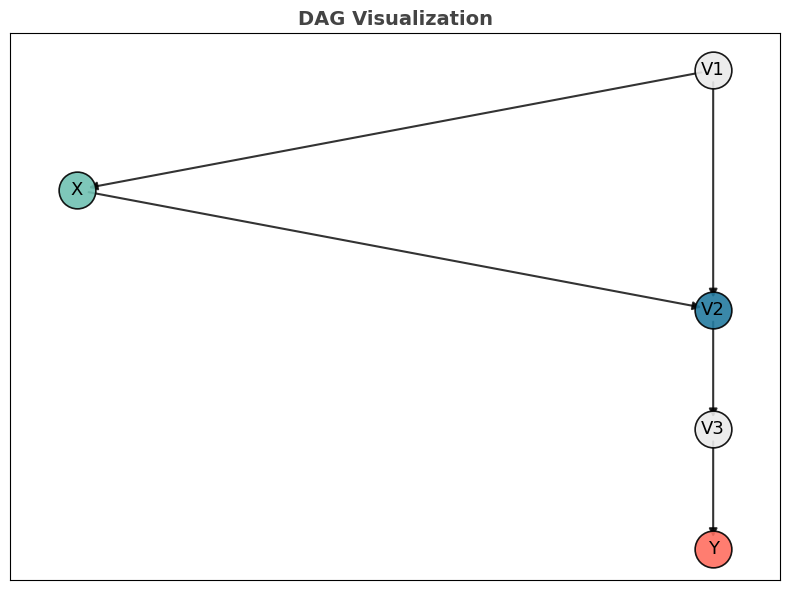

In [ ]:
start_nodes = {"X"}
end_nodes = {"Y"}
minsepG1 = findMinSepInDAG(G1, X=start_nodes, Y=end_nodes)
draw(G1, inend=(start_nodes, end_nodes), Z=minsepG1)

In [ ]:
minsepG1 = findMinSepInDAG(G1, X=start_nodes, Y=end_nodes)
print("Minimal d-separator: ", minsepG1)

Minimal d-separator:  {'V2'}


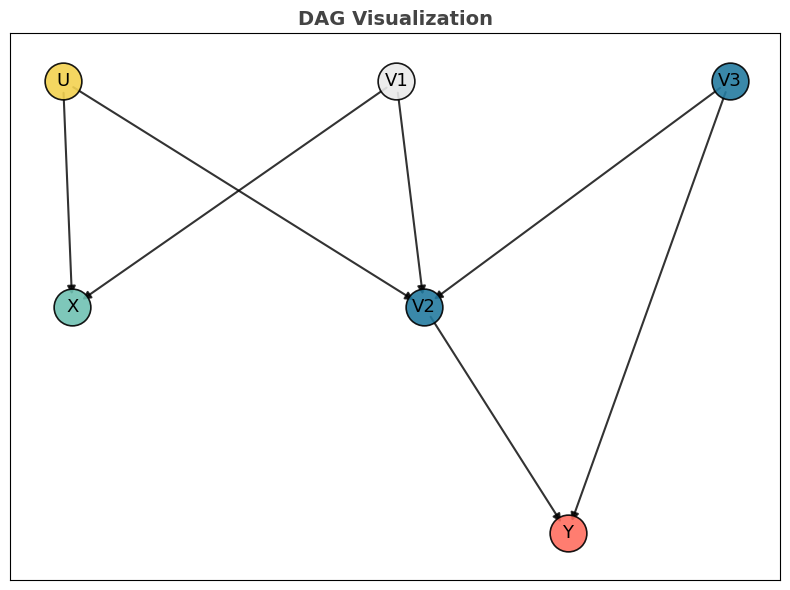

In [ ]:
start_nodes = {"X"}
end_nodes = {"Y"}
unobs = {"U"}
minsepG2 = findMinSepInDAG(G2, X=start_nodes, Y=end_nodes, notR=unobs)
draw(G2, inend=(start_nodes, end_nodes), unobs=unobs, Z=minsepG2)

In [ ]:
print("Minimal d-separator: ", minsepG2)

Minimal d-separator:  {'V3', 'V2'}


## General Algorithm

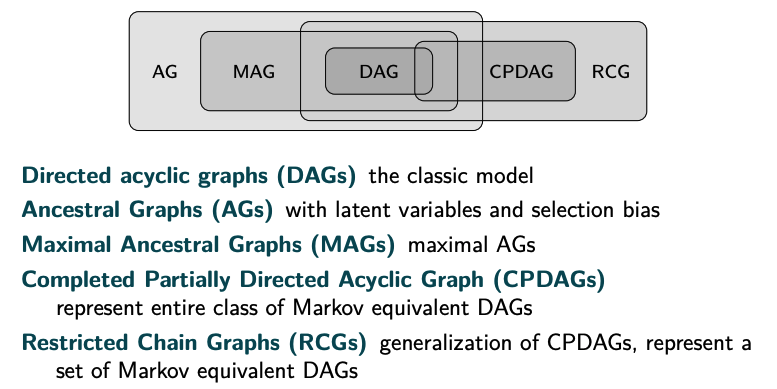

The general algorithm is valid, as stated earlier, for AGs and RCGs.  

Furthermore, given the relationships $ MAG \subseteq AG $ and  $CPDAG \subseteq RCG $, our algorithms are also valid for MAGs and CPDAGs.

In [ ]:
def draw_mixed_graph(G_mixed, inend: Tuple[Set[str], Set[str]] = (set(), set()),
                     unobs: Set[str] = set(), Z: Set[str] = set()):
    """Display a mixed graph"""

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G_mixed, seed=42)

    start_nodes, end_nodes = inend

    color_map = {
        "start": "#7FC8A9",
        "end": "#FF6F61",
        "observed": "#4F6D7A",
        "unobserved": "#FFD166",
        "default": "white"
    }

    node_colors = [(
        color_map["start"] if v in start_nodes else
        color_map["end"] if v in end_nodes else
        color_map["observed"] if v in Z else
        color_map["unobserved"] if v in unobs else
        color_map["default"]
    ) for v in G_mixed.nodes()]

    nx.draw_networkx_nodes(G_mixed, pos, node_color=node_colors, edgecolors="black",
                           node_size=600, linewidths=1.2)

    nx.draw_networkx_labels(G_mixed, pos, font_size=12)

    directed_edges = G_mixed.get_graphs(edge_type="directed")
    nx.draw_networkx_edges(directed_edges, pos, edge_color="#0077b6", width=2, arrows=True)

    bidirected_edges = G_mixed.get_graphs(edge_type="bidirected")
    nx.draw_networkx_edges(bidirected_edges, pos, edge_color="#2a9d8f", width=2,
                           connectionstyle="arc3,rad=0.2", arrows=True)

    undirected_edges = G_mixed.get_graphs(edge_type="undirected")
    nx.draw_networkx_edges(undirected_edges, pos, edge_color="#e63946", width=2, style="dashed")

    plt.legend(handles=[
        plt.Line2D([0], [0], color="#0077b6", lw=2, label="Directed"),
        plt.Line2D([0], [0], color="#2a9d8f", lw=2, linestyle="-", label="Bidirected"),
        plt.Line2D([0], [0], color="#e63946", lw=2, linestyle="dashed", label="Undirected")
    ], loc="upper left", fontsize=10)

    plt.title("Mixed Graph", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()

We reconstruct the previously tested DAGs and re-evaluate them using general algorithms to verify whether we obtain the same results.

In [ ]:
directed_G1 = DiGraph([
    ("X", "V2"),
    ("V2", "V3"),
    ("V3", "Y"),
    ("V1", "X"),
    ("V1", "V2")
])

bidirected_G1 = nx.Graph([])
undirected_G1 = nx.Graph([])

all_nodes_G1 = ["X", "Y", "V1", "V2", "V3"]
directed_G1.add_nodes_from(all_nodes_G1)
bidirected_G1.add_nodes_from(all_nodes_G1)
undirected_G1.add_nodes_from(all_nodes_G1)

G1 = pg.networkx.MixedEdgeGraph(
    graphs=[directed_G1, bidirected_G1, undirected_G1],
    edge_types=["directed", "bidirected", "undirected"]
)

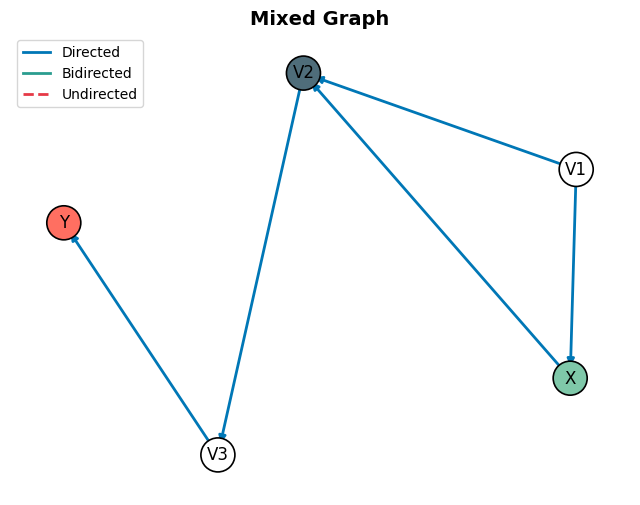

In [ ]:
start_nodes = {"X"}
end_nodes = {"Y"}
minsepG1 = find_min_sep(G1, {"X"}, {"Y"})
draw_mixed_graph(G1, inend=(start_nodes, end_nodes), Z=minsepG1)

In [ ]:
print("Minimal d-separator: ", minsepG1)

Minimal d-separator:  {'V2'}


In [ ]:
test_min_sep(G1, X={"X"}, Y={"Y"}, Z={"V3", "V2"})

False

In [ ]:
test_min_sep(G1, X={"X"}, Y={"Y"}, Z={"V2"})

True

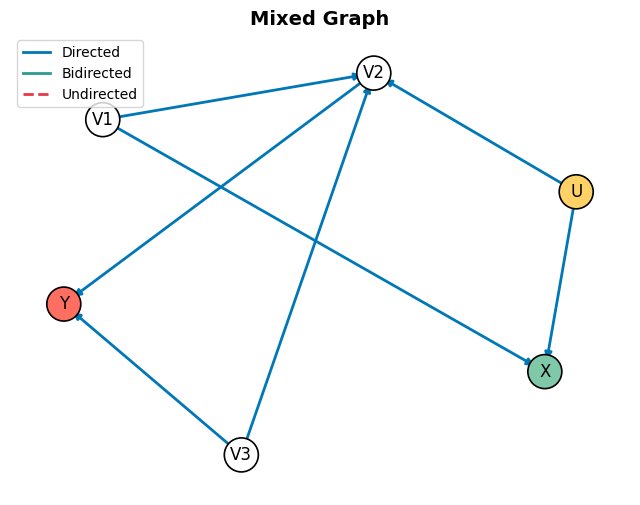

In [ ]:
directed_G2 = DiGraph([
    ("V1", "X"),
    ("V1", "V2"),
    ("U", "X"),
    ("U", "V2"),
    ("V3", "V2"),
    ("V2", "Y"),
    ("V3", "Y")
])

bidirected_G2 = nx.Graph([])
undirected_G2 = nx.Graph([])

all_nodes_G2 = ["X", "Y", "V1", "V2", "V3", "U"]
directed_G2.add_nodes_from(all_nodes_G2)
bidirected_G2.add_nodes_from(all_nodes_G2)
undirected_G2.add_nodes_from(all_nodes_G2)

G2 = pg.networkx.MixedEdgeGraph(
    graphs=[directed_G2, bidirected_G2, undirected_G2],
    edge_types=["directed", "bidirected", "undirected"]
)

draw_mixed_graph(G2, inend=({"X"}, {"Y"}), unobs={"U"})

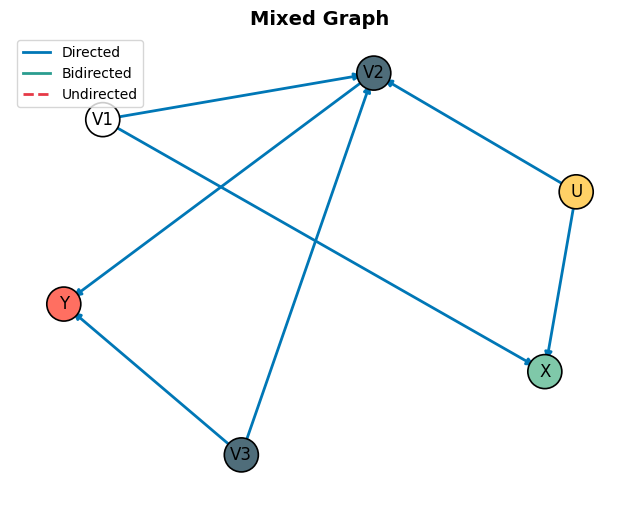

In [ ]:
start_nodes = {"X"}
end_nodes = {"Y"}
unobs = {"U"}
minsepG2 = find_min_sep(G2, X=start_nodes, Y=end_nodes, notR=unobs)
draw_mixed_graph(G2, inend=(start_nodes, end_nodes), unobs=unobs, Z=minsepG2)

In [ ]:
print("Minimal d-separator: ", minsepG2)

Minimal d-separator:  {'V3', 'V2'}


In [ ]:
test_min_sep(G2, X={"X"}, Y={"Y"}, Z={"V2", "V3"}, notR={"U"})

True

In [ ]:
test_min_sep(G2, X={"X"}, Y={"Y"}, Z={"V3", "V1"}, notR={"U"})

False

We also construct a CPDAG to verify its applicability to other types of graphs and to evaluate the performance of the algorithms.

**Completed Partially Directed Acyclic Graphs (CPDAGs):** A CPDAG is a compact representation of a Markov equivalence class of Directed Acyclic Graphs (DAGs). In a CPDAG, edges can be either directed or undirected, where:  

- A directed edge $ A \to B $ indicates that this direction is consistent across all DAGs within the equivalence class.  

- An undirected edge $ A — B $ signifies that the orientation of the edge may vary among the DAGs in the equivalence class.

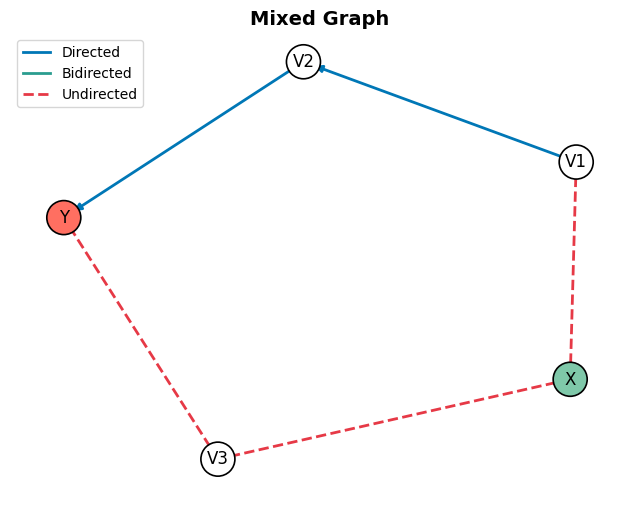

In [ ]:
# CPDAG from Teramoto, Reiji & Saito, Chiaki & Funahashi, Shin-Ichi. (2014). Estimating causal effects with a non-paranormal method for the design of efficient intervention experiments. BMC bioinformatics. 15. 228. 10.1186/1471-2105-15-228.

directed_G = nx.DiGraph([("V2", "Y"), ("V1", "V2")])
bidirected_G = nx.Graph([])
undirected_G = nx.Graph([("V1", "X"), ("X", "V3"), ("V3", "Y")])

all_nodes = ["X", "V1", "V2", "V3", "Y"]
directed_G.add_nodes_from(all_nodes)
bidirected_G.add_nodes_from(all_nodes)
undirected_G.add_nodes_from(all_nodes)

CPDAG = pg.networkx.MixedEdgeGraph(
    graphs=[directed_G, bidirected_G, undirected_G],
    edge_types=["directed", "bidirected", "undirected"],
)

draw_mixed_graph(CPDAG, inend=({"X"}, {"Y"}))

In [ ]:
reachable(CPDAG, {"X"}, A=possible_an(CPDAG, {"X", "Y"})|{"X", "Y"}, Z={"V3", "V1"})

{'V1', 'V3', 'X'}

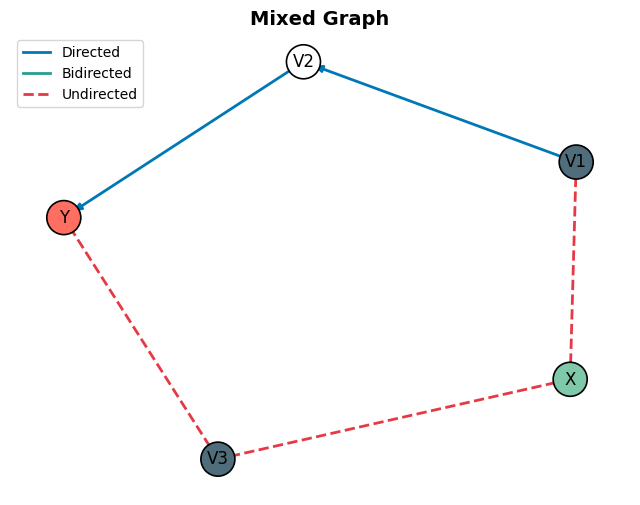

Minimal d-separator:  {'V3', 'V1'}


In [ ]:
start_nodes = {"X"}
end_nodes = {"Y"}
minsepCPDAG = find_min_sep(CPDAG, X=start_nodes, Y=end_nodes)
draw_mixed_graph(CPDAG, inend=(start_nodes, end_nodes), Z=minsepCPDAG)
print("Minimal d-separator: ", minsepCPDAG)

In [ ]:
test_min_sep(CPDAG, {"X"}, {"Y"}, Z=minsepCPDAG)

True

In [ ]:
test_min_sep(CPDAG, {"X"}, {"Y"}, Z={"V1"})

False

In [ ]:
test_min_sep(CPDAG, {"X"}, {"Y"}, Z={"V1", "V2", "V3"})

False

# Conclusion

In conclusion, we have successfully verified that both the **DAG-specific algorithms** and the more **general algorithms** are applicable and functional. The results obtained are consistent with the findings and tests presented in the reference paper.

Furthermore, we confirmed their robustness by applying them to an additional generic graph, demonstrating their reliability across different structures.